# Dwarf Galaxies in VFS Halpha Survey

In [1]:
import os
from matplotlib import pyplot as plt
import numpy as np
from astropy.table import Table
import glob
import warnings
warnings.filterwarnings('ignore')

homedir = os.getenv("HOME")
plotdir = homedir + "/research/Virgo/hapypost/plots/"

%load_ext autoreload
%autoreload 2

from hapypost.io.vfs_tables import VTables


# TODO

- [x] cumulative distribution of redshifts for dwarfs in each environment category
- [ ] redo plot but w/SFR based on SEDs
  - [ ] main sequence fit
  - [ ] sf is within 0.3 dex of the MS
  - [ ] quiescent is >0.3 dex below MS

# Redshift Distribution of Dwarfs vs Environment

table directory = /Users/rfinn/research/Virgo/tables-north/v2/


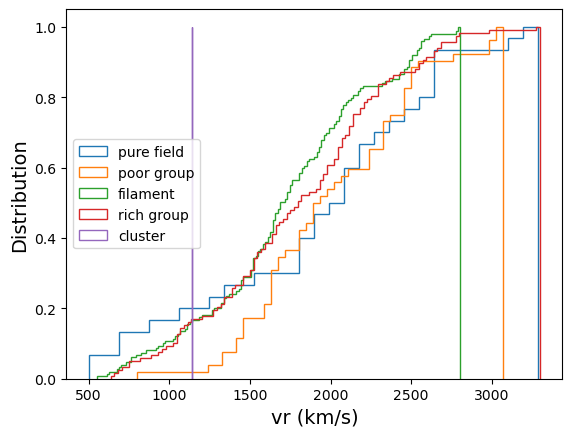

In [65]:
%run ~/github/hapypost/scripts/dwarf_galaxies.py --tabledir ~/research/Virgo/tables-north/v2/ --plotdir $plotdir

plot_dwarf_redshift_by_environment(
    v,
    plotdir,
    outfile_root="dwarf_redshift_by_environment",
    haobs_key="HAPY_HAS_OBS",
    show=True,
    title=True,
    logmstar_min=6.5,
    logmstar_max=8.5,
)

# Fraction of Halpha Detections vs Environment

table directory = /Users/rfinn/research/Virgo/tables-north/v2/
number of dwarf galaxies observed with Halpha = 318
number of dwarf galaxies detected with Halpha = 143


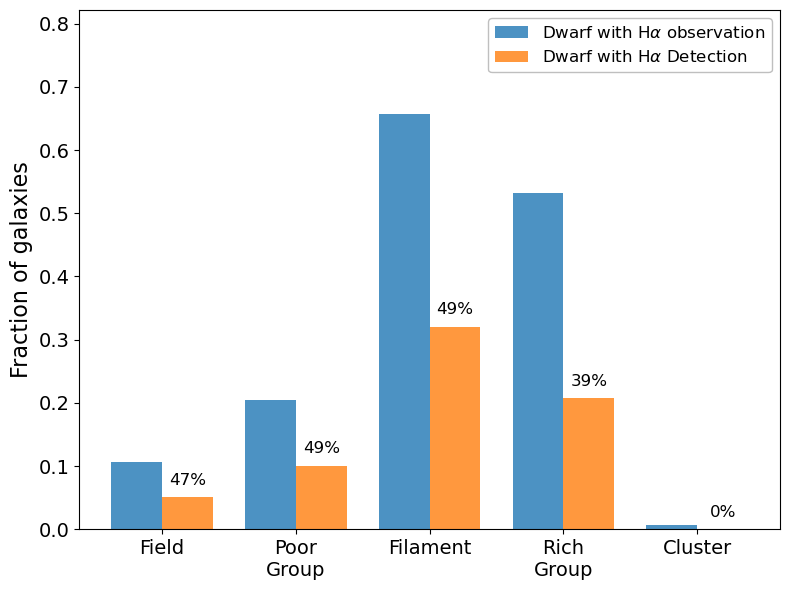

In [132]:
%run ~/github/hapypost/scripts/dwarf_galaxies.py --tabledir ~/research/Virgo/tables-north/v2/ --plotdir $plotdir
plot_environment_distribution(v, plotdir,show=True, logmstar_min=7.)


table directory = /Users/rfinn/research/Virgo/tables-north/v2/


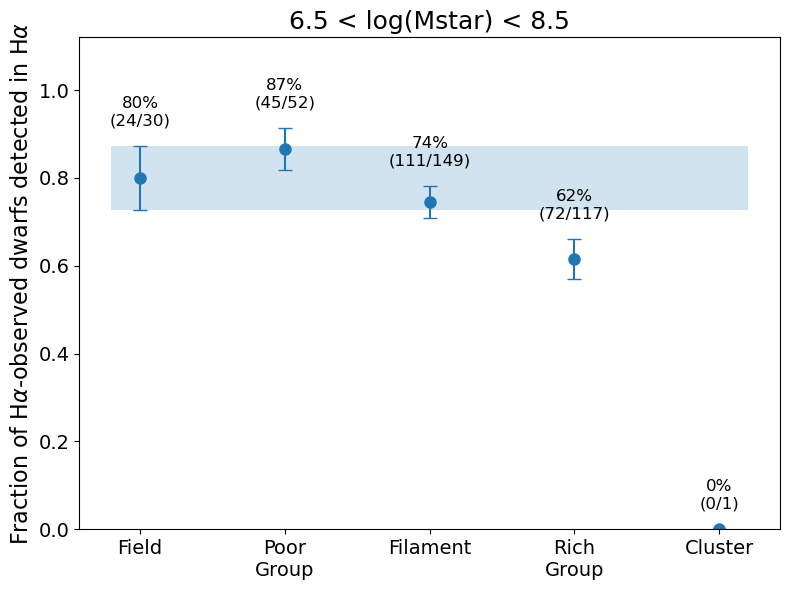

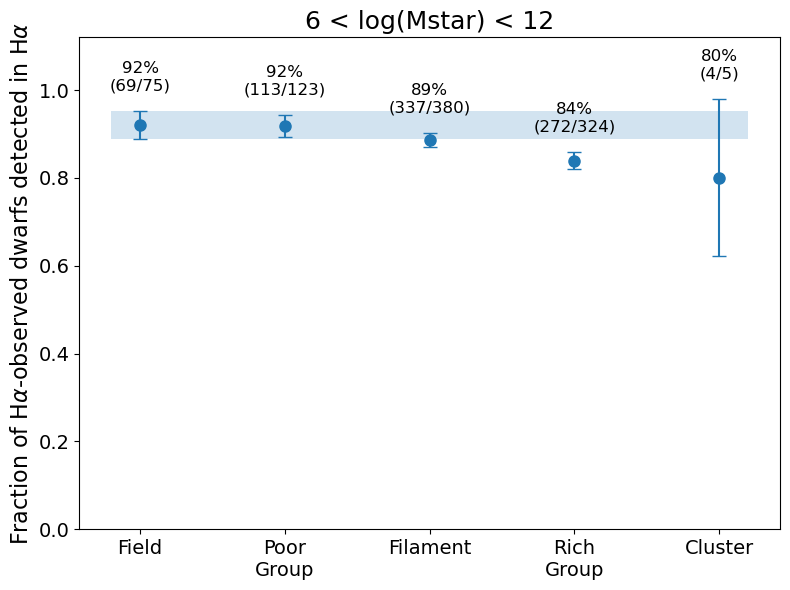

In [139]:
%run ~/github/hapypost/scripts/dwarf_galaxies.py --tabledir ~/research/Virgo/tables-north/v2/ --plotdir $plotdir
SNR_CUT=3.5
NPIX = 1
t = plot_halpha_detection_completeness_by_environment(
    v,
    plotdir,
    outfile_root="dwarf_halpha_detection_completeness_by_environment",
    haobs_key="HAPY_HAS_OBS",
    show=True,
    title=True,
    logmstar_min=6.5,
    logmstar_max=8.5,
    ha_snr_cut=SNR_CUT,
    npix=NPIX,
)


t = plot_halpha_detection_completeness_by_environment(
    v,
    plotdir,
    outfile_root="dwarf_halpha_detection_completeness_by_environment",
    haobs_key="HAPY_HAS_OBS",
    show=True,
    title=True,
    logmstar_min=6,
    logmstar_max=12,
    ha_snr_cut=SNR_CUT,
    npix=NPIX,
)

# SFR-Mstar Relation

table directory = /Users/rfinn/research/Virgo/tables-north/v2/


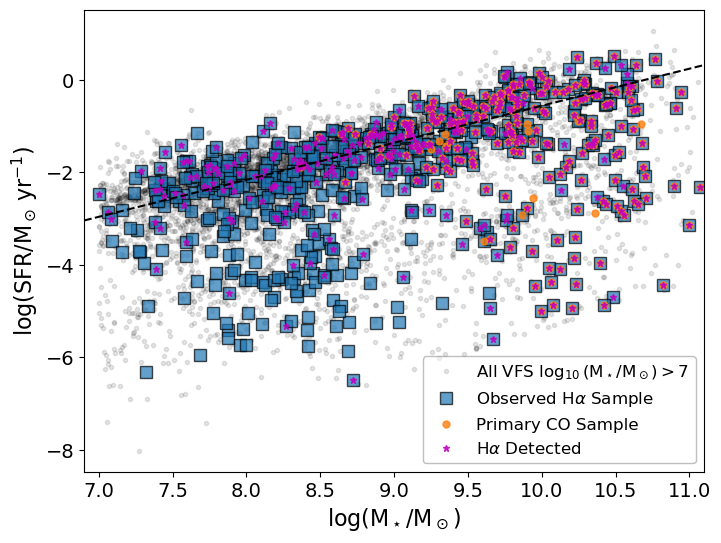

In [127]:
%run ~/github/hapypost/scripts/dwarf_galaxies.py --tabledir ~/research/Virgo/tables-north/v2/ --plotdir $plotdir
plot_sfr_mstar_sample(v, plotdir)
#plt.show()

# Select dwarfs on MS but no halpha detection

In [123]:
logmstar = get_logmstar(v)
logsfr = get_logsfr(v)
dsfr = get_dsfr(logmstar,logsfr)

ms_flag = np.abs(dsfr) < 1


dwarf_flag = get_dwarf_flag(v,logmstar_min=7.5,logmstar_max=8.5)
ha_detect_flag = get_halpha_detection_flag(v,snr_cut=3.9)
has_ha = v.halpha['HAPY_HAS_OBS']


# MS dwarfs with no halpha
ms_dwarf_no_ha = dwarf_flag & ms_flag & has_ha & ~ha_detect_flag

print(f"number of MS dwarfs with no halpha = {np.sum(ms_dwarf_no_ha)}")

number of MS dwarfs with no halpha = 38


In [121]:
np.arange(len(v.main))[ms_dwarf_no_ha]

array([1168, 1587, 1832, 1912, 2049, 2098, 2175, 2660, 2671, 2738, 2766,
       2792, 3014, 3020, 3035, 3202, 3251, 3297, 3362, 3369, 3446, 3475,
       3483, 3490, 3491, 3493, 3504, 3674, 3712, 4081, 4104, 4257, 5844,
       5952, 6194, 6327, 6338, 6372, 6386, 6392, 6428, 6512])

In [109]:
ha_detect_flag[582]

True

In [110]:
v.main['VFID'][582]

'VFID0582'

In [111]:
v.halpha['CSGR_HAPY_SNP_DET'][582] > 5

False

In [112]:
# 2049 is an example of blue but no halpha
# what is stellar mass?
logmstar[2049]

8.291269650933524

In [117]:
ha_detect_flag[2049]

False

In [118]:
dsfr[2049]

-0.9244353066828919

In [126]:
v.main['vr'][2175]

1276.0

# PCA and Clustering

- PCA
- UMAP
- density clustering

In [198]:
%run ~/github/hapypost/scripts/dwarf_galaxies.py --tabledir ~/research/Virgo/tables-north/v2/ --plotdir $plotdir

table directory = /Users/rfinn/research/Virgo/tables-north/v2/


### Define Variables

In [199]:
# define variables to use for PCA, UMAP and density analysis

# cigale stellar mass
logmstar = get_logmstar(v)

# cigale sfr
logsfr = get_logsfr(v)

# cigale distance from main sequence (similar to sSFR)
dsfr = get_dsfr(logmstar,logsfr)

# get science ready
sci_flag = science_ready_mask(v)

# select dwarfs
dwarf_flag = get_dwarf_flag(v,logmstar_min=7.5,logmstar_max=9)  & sci_flag

# get ratio of R75
outer_size_ratio = get_outer_size_ratio(v)

# get ratio of second moment sigma
moment2_sigma_ratio = get_moment_ratio(v)

# get ratio of halpha to r flux
flux_ratio = get_flux_ratio(v)

# R-band concentration
c30 = v.halpha['R_C30']

# HAPY halpha filling fraction
hapy_fillfrac = v.halpha['CSGR_HAPY_FILLFRAC']

# get g-r color in the AP06
gr_color = get_gr_color(v)

# get difference in r vs halpha asymmetry
delta_asym = get_hapy_delta_asym(v)
r_asym = get_hapy_r_asym(v.halpha)
h_asym = get_hapy_h_asym(v.halpha)


# Gini  
delta_gini_hapy = get_hapy_delta_gini(v)

delta_gini_sc = get_sc_delta_gini(v)


# M20
delta_m20_hapy = get_hapy_delta_m20(v)

In [200]:
# Environment variables

# sigma 5
log_sigma5 = v.env['n5th_2D']

# distance to virgo
dx = v.env["distSGX_Virgo"]
dy = v.env["distSGY_Virgo"]
dz = v.env["distSGZ_Virgo"]
dist_virgo_Mpc = np.sqrt(dx**2 + dy**2 + dz**2)

# halo mass from Kourchi & Tully
log_halo_mass = v.kt['log_Mass_lum_adapted']



### Correlation Matrix

In [201]:

features = {
    "logMstar": logmstar,
    #"logSFR": logsfr,
    "dSFR": dsfr,
    "outer_size_ratio": outer_size_ratio,
    #"moment2_sigma_ratio": moment2_sigma_ratio,
    "flux_ratio": flux_ratio,
    "R_C30": c30,
    "Halpha_fillfrac": hapy_fillfrac,
    "g_minus_r": gr_color,
    "delta_asym": delta_asym,
    "r_asym":r_asym,
    "h_asym":h_asym,
    "delta_gini_hapy":delta_gini_hapy,
    "delta_gini_sc":delta_gini_sc,
    "delta_m20_hapy":delta_m20_hapy,
}

df = pd.DataFrame(features)

# Optional: use log versions for strongly positive ratios
# This is usually better for PCA/UMAP.
#for col in ["outer_size_ratio", "moment2_sigma_ratio", "flux_ratio"]:
for col in ["outer_size_ratio",  "flux_ratio"]:
    df[f"log_{col}"] = np.log10(df[col])

# Select feature columns for PCA/UMAP
feature_cols = [
    "logMstar",
    #"logSFR",
    "dSFR",
    "log_outer_size_ratio",
    #"log_moment2_sigma_ratio",
    "log_flux_ratio",
    "R_C30",
    "Halpha_fillfrac",
    "g_minus_r",
    "delta_asym",
    "r_asym",
    "h_asym",
    "delta_gini_hapy",
    "delta_gini_sc",
    "delta_m20_hapy",
]

# Require dwarf sample and finite values
useflag = np.array(dwarf_flag, dtype=bool)

for col in feature_cols:
    useflag &= np.isfinite(df[col].values)

df_use = df.loc[useflag].copy()

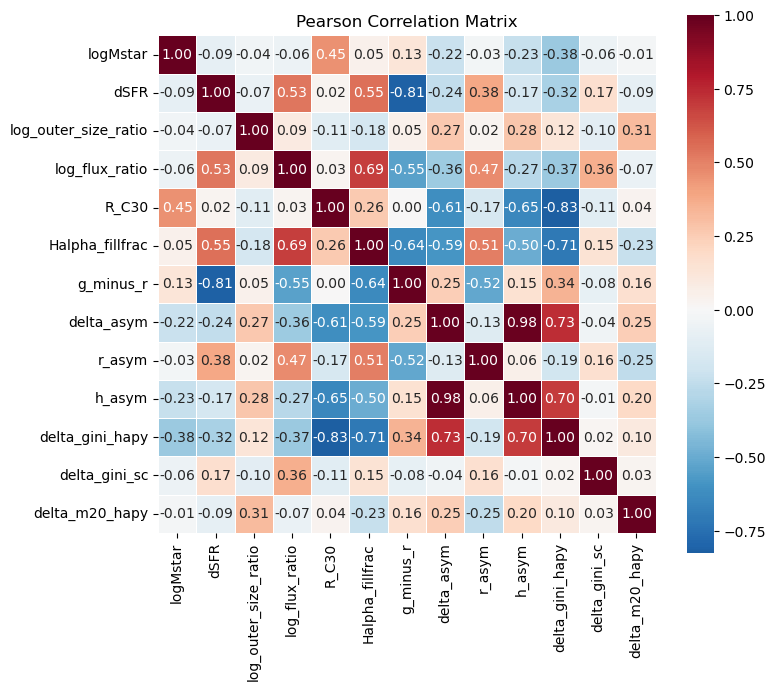

In [202]:
import seaborn as sns
import matplotlib.pyplot as plt

# Variables used in the UMAP
feature_cols_umap = [
    "logMstar",
    "dSFR",
    "log_outer_size_ratio",
    "log_flux_ratio",
    "R_C30",
    "Halpha_fillfrac",
    "g_minus_r",
    "delta_asym",
    "r_asym",
    "h_asym",
    "delta_gini_hapy",
    "delta_gini_sc",
    "delta_m20_hapy",
]

# Pearson correlation
corr = df_use[feature_cols_umap].corr(method="pearson")

plt.figure(figsize=(8,7))
sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="RdBu_r",
    center=0,
    square=True,
    linewidths=0.5,
)
plt.title("Pearson Correlation Matrix")
plt.tight_layout()
plt.show()

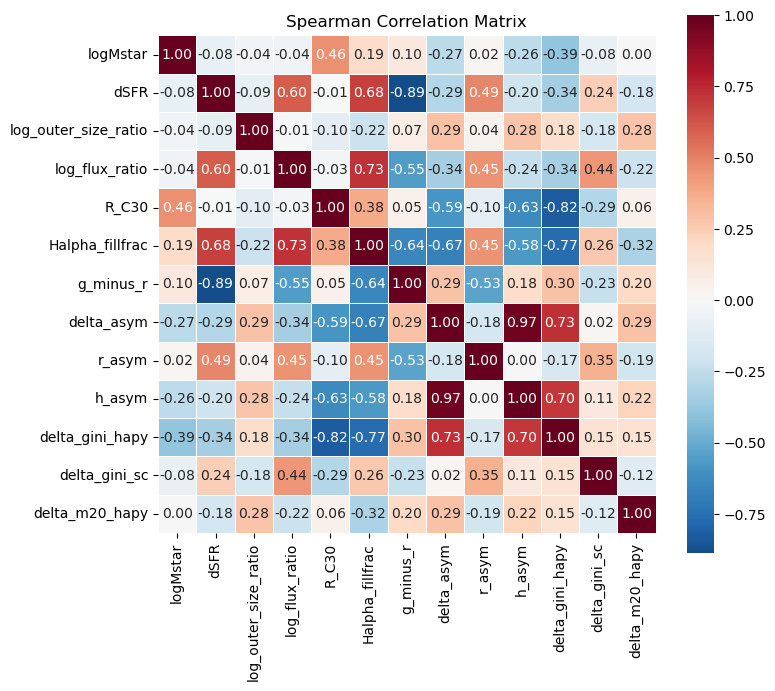

In [170]:
corr_s = df_use[feature_cols_umap].corr(method="spearman")

plt.figure(figsize=(8,7))
sns.heatmap(
    corr_s,
    annot=True,
    fmt=".2f",
    cmap="RdBu_r",
    center=0,
    square=True,
    linewidths=0.5,
)
plt.title("Spearman Correlation Matrix")
plt.tight_layout()
plt.show()

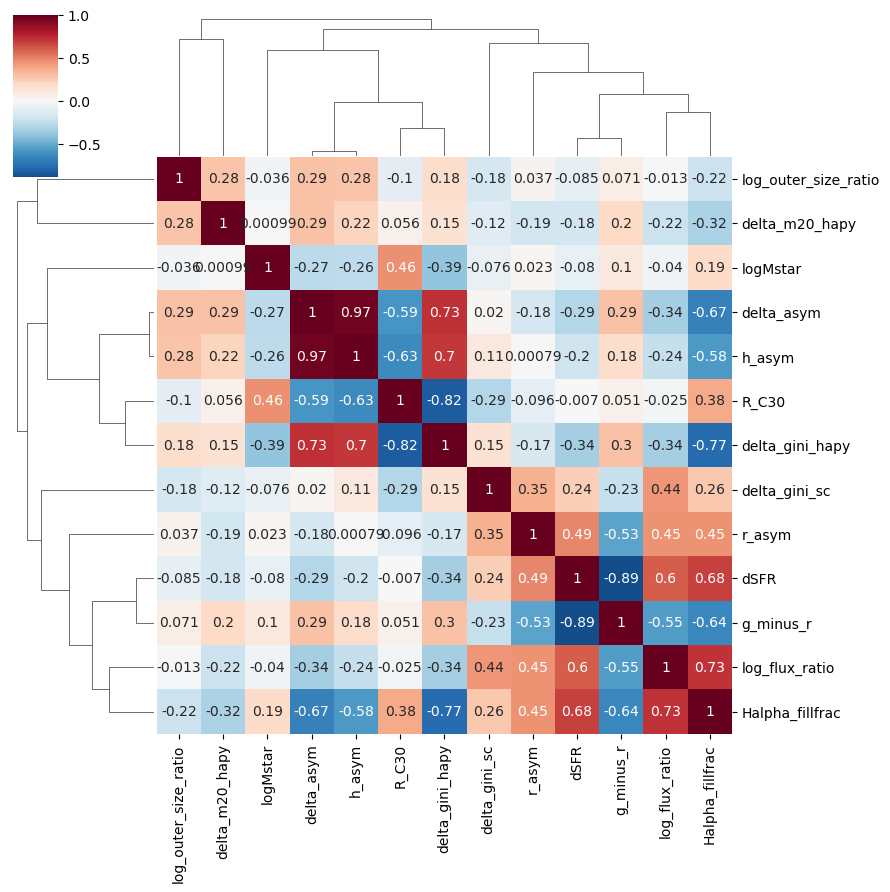

In [203]:
from scipy.cluster.hierarchy import linkage
from scipy.spatial.distance import squareform

# Convert correlation into a distance matrix
dist = 1 - np.abs(corr_s)

# linkage expects condensed distance matrix
Z = linkage(squareform(dist, checks=False), method="average")

sns.clustermap(
    corr_s,
    row_linkage=Z,
    col_linkage=Z,
    cmap="RdBu_r",
    center=0,
    annot=True,
    figsize=(9,9),
)
plt.show()

### PCA Analysis

Number of galaxies used for PCA/UMAP = 209
         logMstar        dSFR  log_outer_size_ratio  log_flux_ratio  \
count  209.000000  209.000000            209.000000      209.000000   
mean     8.260533   -0.765140             -0.068695       -1.848330   
std      0.390110    1.284471              0.264358        0.422362   
min      7.518323   -4.902033             -0.827957       -3.073985   
25%      7.912625   -1.732428             -0.223516       -2.118781   
50%      8.299649   -0.303556             -0.073966       -1.848309   
75%      8.587323    0.186945              0.079068       -1.577751   
max      8.994141    1.278050              0.839623       -0.655531   

            R_C30  Halpha_fillfrac   g_minus_r  delta_asym      r_asym  
count  209.000000       209.000000  209.000000  209.000000  209.000000  
mean     0.280410         0.107038    0.201339    1.293092    0.167426  
std      0.093582         0.123038    0.056692    0.492179    0.093173  
min      0.103551        

,PC1,PC2
g_minus_r,-0.445884,0.193336
delta_asym,-0.307563,-0.464007
log_outer_size_ratio,-0.071888,-0.236015
logMstar,0.007740,0.467028
R_C30,0.114210,0.608918
r_asym,0.335434,-0.238106
dSFR,0.418449,-0.159470
log_flux_ratio,0.418948,-0.107616
Halpha_fillfrac,0.474540,0.094940


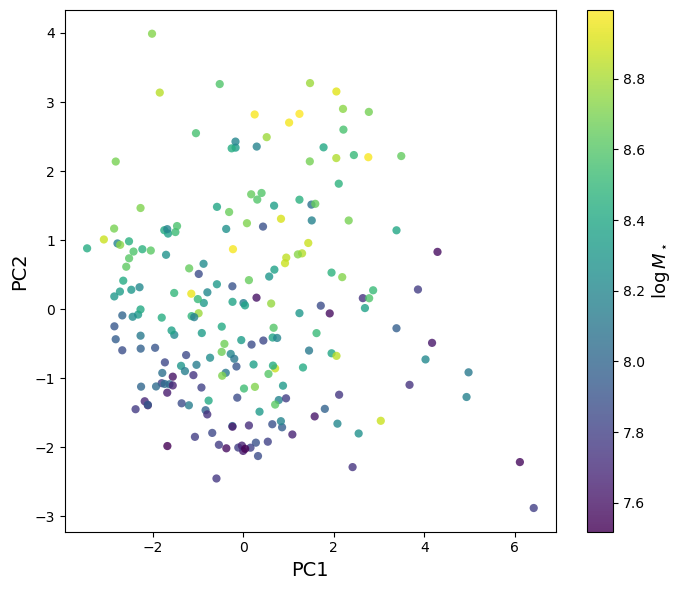

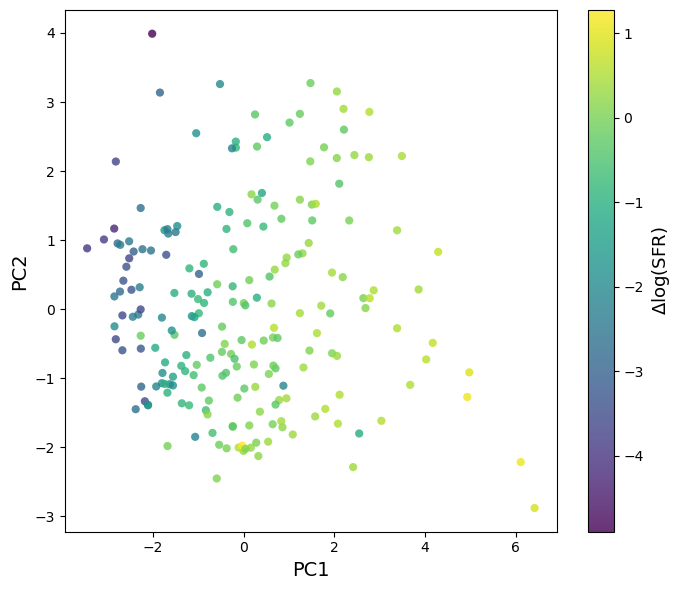

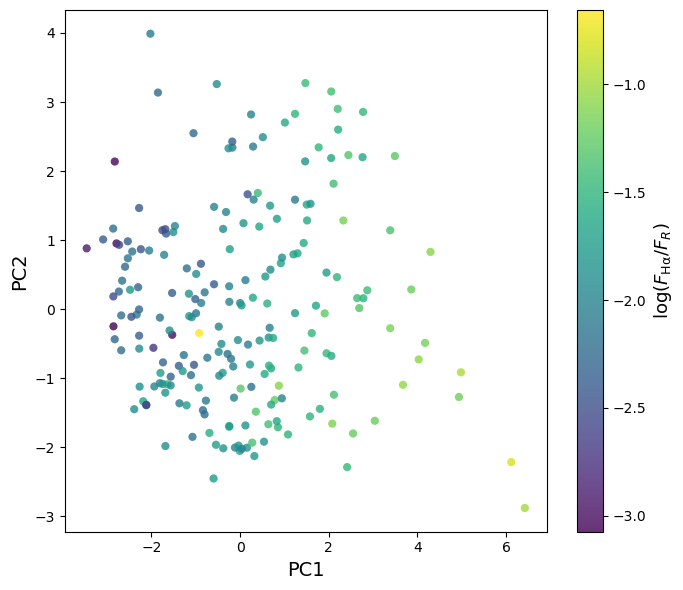

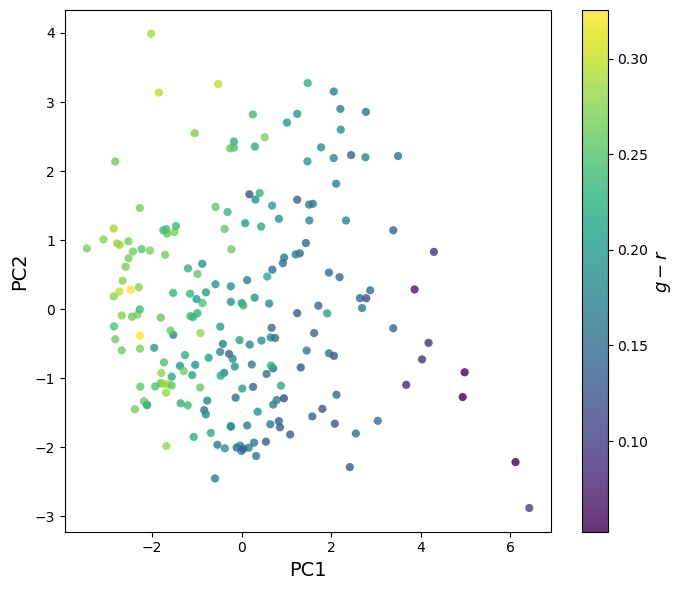

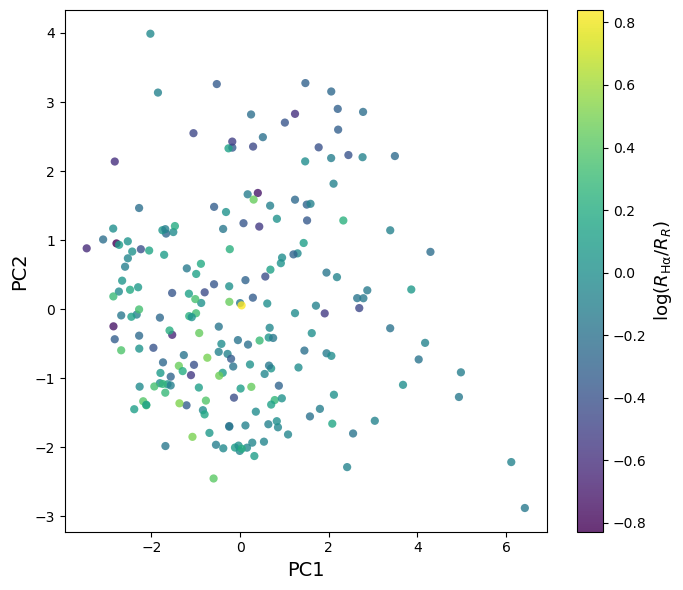

In [204]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Select feature columns for PCA/UMAP
feature_cols = [
    "logMstar",
    #"logSFR",
    "dSFR",
    "log_outer_size_ratio",
    #"log_moment2_sigma_ratio",
    "log_flux_ratio",
    "R_C30",
    "Halpha_fillfrac",
    "g_minus_r",
    "delta_asym",
    "r_asym",
    #"h_asym", # dropping h_asym b/c it's strongly correlated with delta_asym
]

# ------------------------------------------------------------
# Build feature table
# ------------------------------------------------------------


print(f"Number of galaxies used for PCA/UMAP = {len(df_use)}")
print(df_use[feature_cols].describe())

# ------------------------------------------------------------
# Standardize features
# ------------------------------------------------------------

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_use[feature_cols])

# ------------------------------------------------------------
# PCA
# ------------------------------------------------------------

pca = PCA(n_components=min(len(feature_cols), 6))
X_pca = pca.fit_transform(X_scaled)

df_use["PC1"] = X_pca[:, 0]
df_use["PC2"] = X_pca[:, 1]

print("\nExplained variance ratio:")
for i, var in enumerate(pca.explained_variance_ratio_):
    print(f"PC{i+1}: {var:.3f}")

# PCA loadings
loadings = pd.DataFrame(
    pca.components_.T,
    index=feature_cols,
    columns=[f"PC{i+1}" for i in range(pca.n_components_)]
)

display(loadings[["PC1", "PC2"]].sort_values("PC1"))

# ------------------------------------------------------------
# PCA plot helper
# ------------------------------------------------------------

def plot_embedding(df, xcol, ycol, color_col, cmap="viridis", label=None):
    fig, ax = plt.subplots(figsize=(7, 6))

    sc = ax.scatter(
        df[xcol],
        df[ycol],
        c=df[color_col],
        s=35,
        alpha=0.8,
        cmap=cmap,
        edgecolor="none",
    )

    ax.set_xlabel(xcol, fontsize=14)
    ax.set_ylabel(ycol, fontsize=14)

    cbar = plt.colorbar(sc, ax=ax)
    cbar.set_label(label or color_col, fontsize=13)

    fig.tight_layout()
    plt.show()


# Example PCA plots
plot_embedding(df_use, "PC1", "PC2", "logMstar", label=r"$\log M_\star$")
plot_embedding(df_use, "PC1", "PC2", "dSFR", label=r"$\Delta \log({\rm SFR})$")
plot_embedding(df_use, "PC1", "PC2", "log_flux_ratio", label=r"$\log(F_{\rm H\alpha}/F_R)$")
plot_embedding(df_use, "PC1", "PC2", "g_minus_r", label=r"$g-r$")
plot_embedding(df_use, "PC1", "PC2", "log_outer_size_ratio", label=r"$\log(R_{\rm H\alpha}/R_R)$")

Text(0, 0.5, 'PC2')

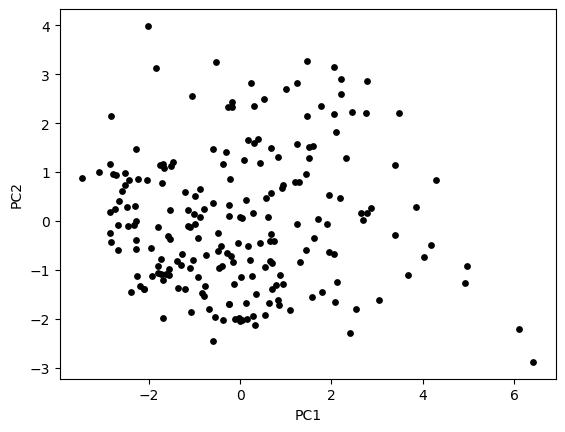

In [205]:
PC1 = df_use["PC1"]
PC2 = df_use["PC2"]
plt.scatter(PC1,PC2,s=15,c='k')

plt.xlabel("PC1")
plt.ylabel("PC2")

#### PCA Biplot

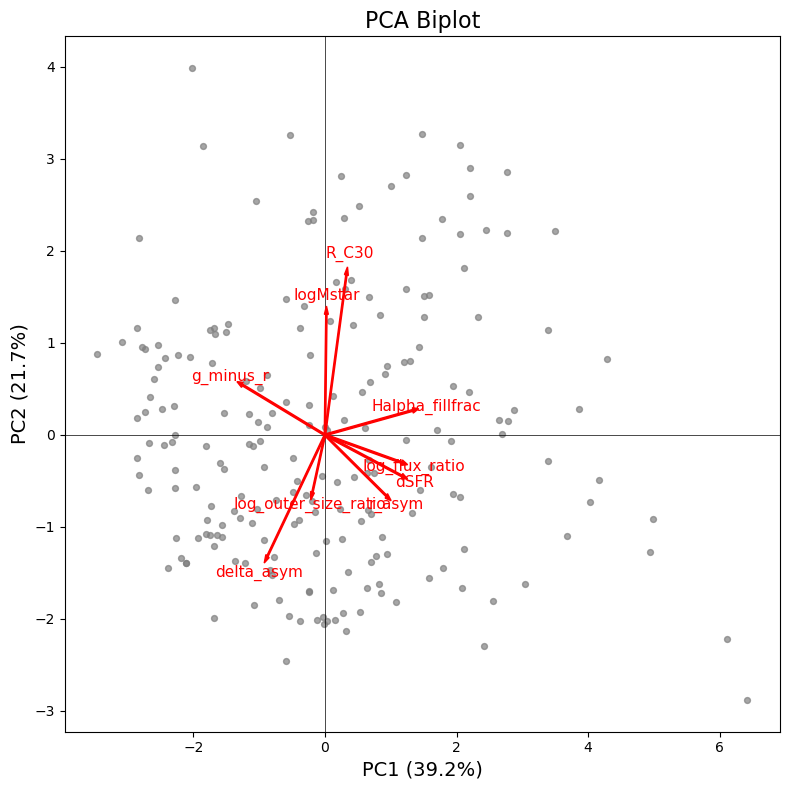

In [206]:
import numpy as np
import matplotlib.pyplot as plt

def plot_pca_biplot(
    X_pca,
    pca,
    feature_names,
    scale_arrows=3.0,
    figsize=(8,8),
):

    fig, ax = plt.subplots(figsize=figsize)

    # ---------------------------------------------------
    # plot galaxies
    # ---------------------------------------------------

    ax.scatter(
        X_pca[:,0],
        X_pca[:,1],
        s=18,
        alpha=0.7,
        color="0.5",
    )

    # ---------------------------------------------------
    # variable vectors
    # ---------------------------------------------------

    loadings = pca.components_.T

    for i, name in enumerate(feature_names):

        x = loadings[i,0] * scale_arrows
        y = loadings[i,1] * scale_arrows

        ax.arrow(
            0,
            0,
            x,
            y,
            color="red",
            width=0.02,
            head_width=0.06,
            length_includes_head=True,
            zorder=5,
        )

        ax.text(
            x*1.08,
            y*1.08,
            name,
            color="red",
            fontsize=11,
            ha="center",
            va="center",
        )

    # ---------------------------------------------------

    ax.axhline(0,color='k',lw=0.5)
    ax.axvline(0,color='k',lw=0.5)

    ax.set_xlabel(
        f"PC1 ({100*pca.explained_variance_ratio_[0]:.1f}%)",
        fontsize=14,
    )

    ax.set_ylabel(
        f"PC2 ({100*pca.explained_variance_ratio_[1]:.1f}%)",
        fontsize=14,
    )

    ax.set_title("PCA Biplot",fontsize=16)

    plt.tight_layout()
    plt.show()


plot_pca_biplot(
    X_pca,
    pca,
    feature_cols,
    scale_arrows=3,
)

### Run UMAP

In [207]:
import numpy as np
import umap
from sklearn.preprocessing import StandardScaler

# ------------------------------------------------------------
# UMAP feature sets
# ------------------------------------------------------------

feature_cols_umap_baseline = [
    "logMstar",
    "dSFR",
    "g_minus_r",
    "log_flux_ratio",
    "Halpha_fillfrac",
    "R_C30",
    "log_outer_size_ratio",
    "r_asym",
    "delta_asym",
]

feature_cols_umap_m20 = feature_cols_umap_baseline + [
    "delta_m20_hapy",
]

# choose which one to run
feature_cols_umap = feature_cols_umap_baseline
# feature_cols_umap = feature_cols_umap_m20

# ------------------------------------------------------------
# Require dwarf sample and finite values
# ------------------------------------------------------------

useflag = np.array(dwarf_flag, dtype=bool)

for col in feature_cols_umap:
    useflag &= np.isfinite(df[col].values)

df_use = df.loc[useflag].copy()

print(f"Number of galaxies used for UMAP = {len(df_use)}")

# ------------------------------------------------------------
# Standardize and run UMAP
# ------------------------------------------------------------

X = df_use[feature_cols_umap].values
X_scaled = StandardScaler().fit_transform(X)

reducer = umap.UMAP(
    n_neighbors=20,
    min_dist=0.1,
    n_components=2,
    metric="euclidean",
    random_state=42,
)

X_umap = reducer.fit_transform(X_scaled)

df_use["UMAP1"] = X_umap[:, 0]
df_use["UMAP2"] = X_umap[:, 1]

Number of galaxies used for UMAP = 209


In [208]:
def plot_umap_color(df, color_col, label=None, cmap="viridis"):
    fig, ax = plt.subplots(figsize=(6.5, 5.8))

    sc = ax.scatter(
        df["UMAP1"],
        df["UMAP2"],
        c=df[color_col],
        s=35,
        alpha=0.85,
        cmap=cmap,
        edgecolor="none",
    )

    ax.set_xlabel("UMAP1", fontsize=14)
    ax.set_ylabel("UMAP2", fontsize=14)

    cbar = plt.colorbar(sc, ax=ax)
    cbar.set_label(label or color_col, fontsize=13)

    fig.tight_layout()
    plt.show()

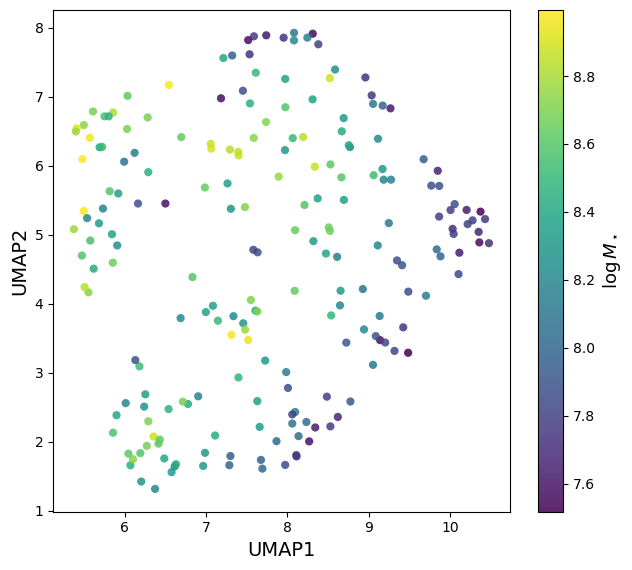

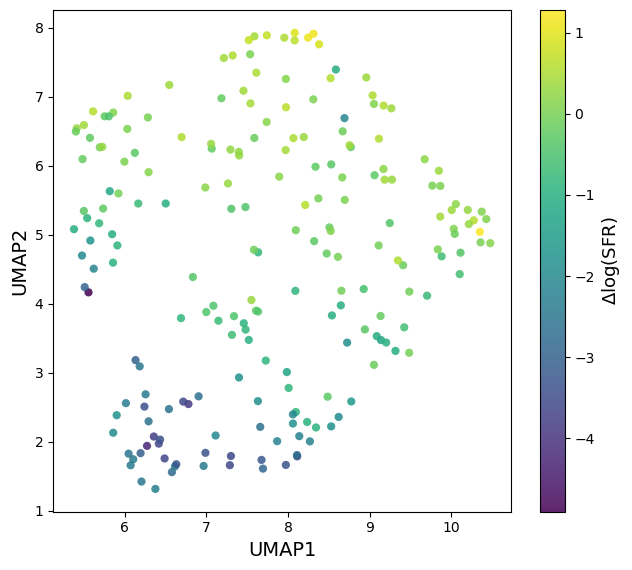

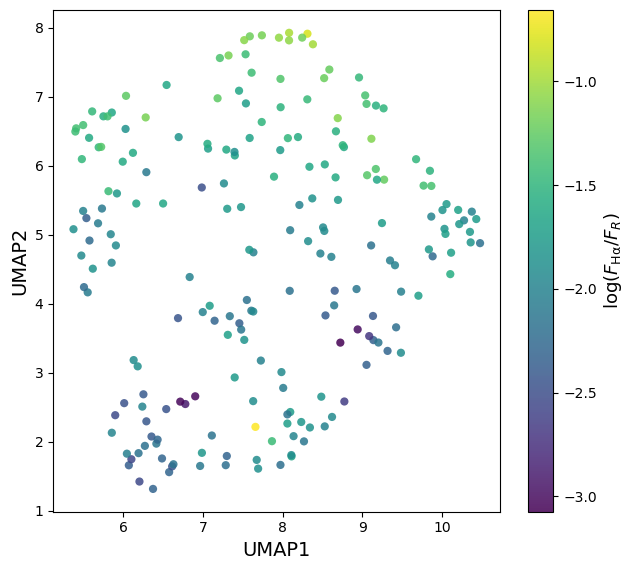

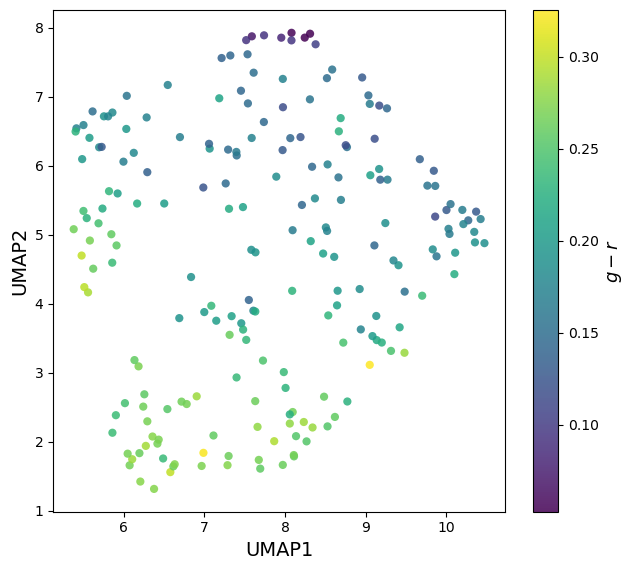

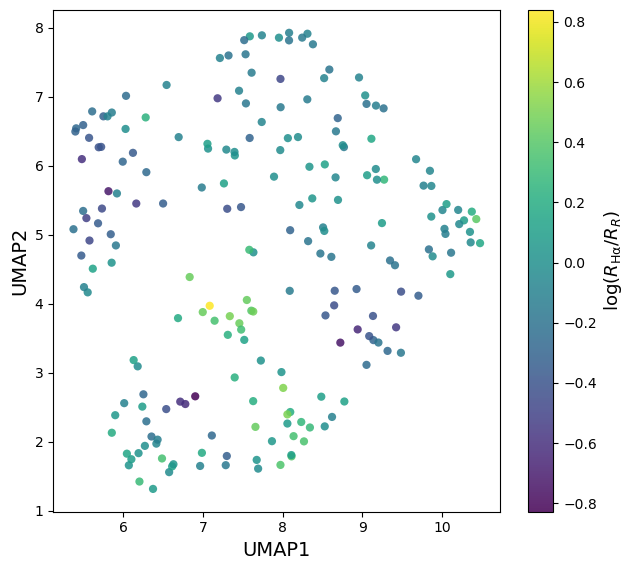

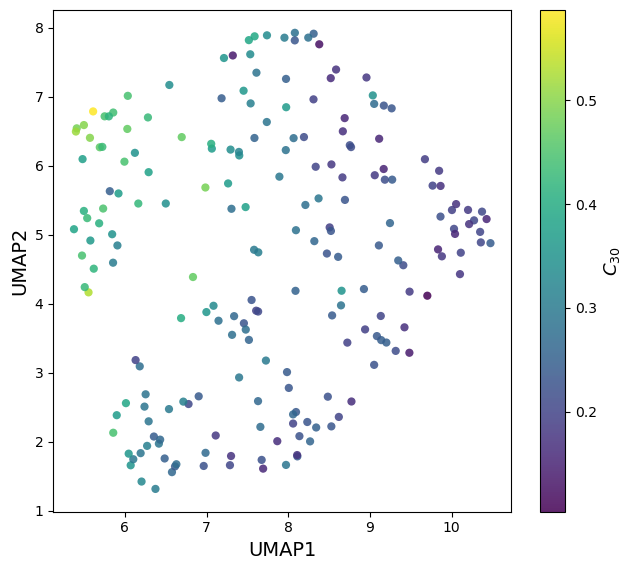

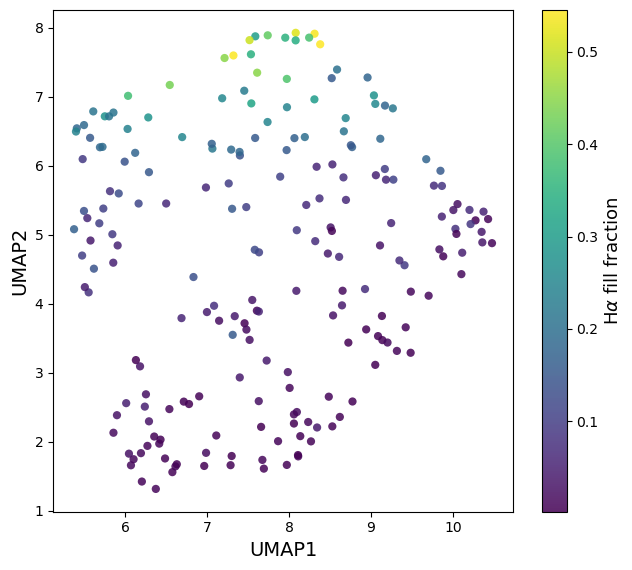

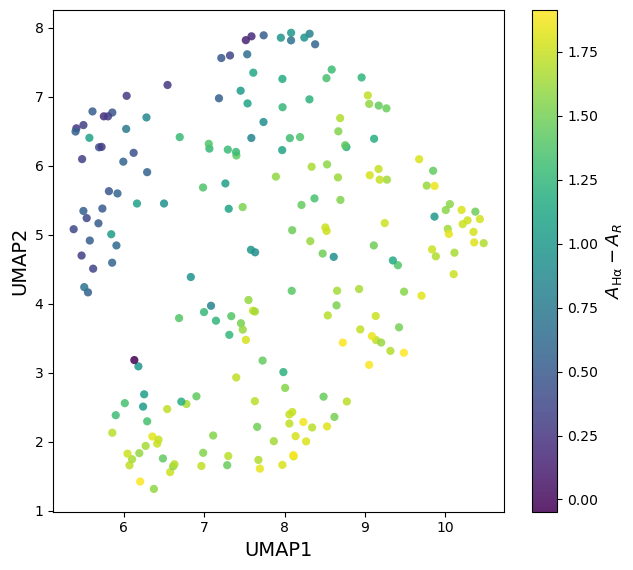

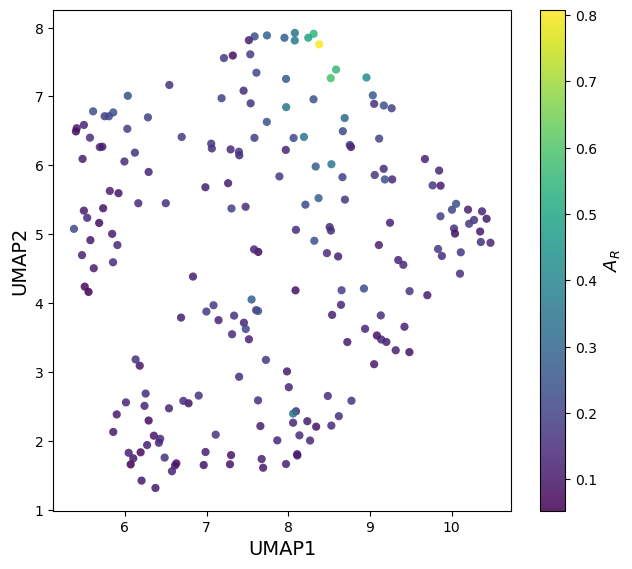

In [242]:
plot_umap_color(df_use, "logMstar", label=r"$\log M_\star$")
plot_umap_color(df_use, "dSFR", label=r"$\Delta \log({\rm SFR})$")
plot_umap_color(df_use, "log_flux_ratio", label=r"$\log(F_{\rm H\alpha}/F_R)$")
plot_umap_color(df_use, "g_minus_r", label=r"$g-r$")
plot_umap_color(df_use, "log_outer_size_ratio", label=r"$\log(R_{\rm H\alpha}/R_R)$")
plot_umap_color(df_use, "R_C30", label=r"$C_{30}$")
plot_umap_color(df_use, "Halpha_fillfrac", label=r"H$\alpha$ fill fraction")
plot_umap_color(df_use, "delta_asym", label=r"$A_{\rm H\alpha}-A_R$")
plot_umap_color(df_use, "r_asym", label=r"$A_R$")

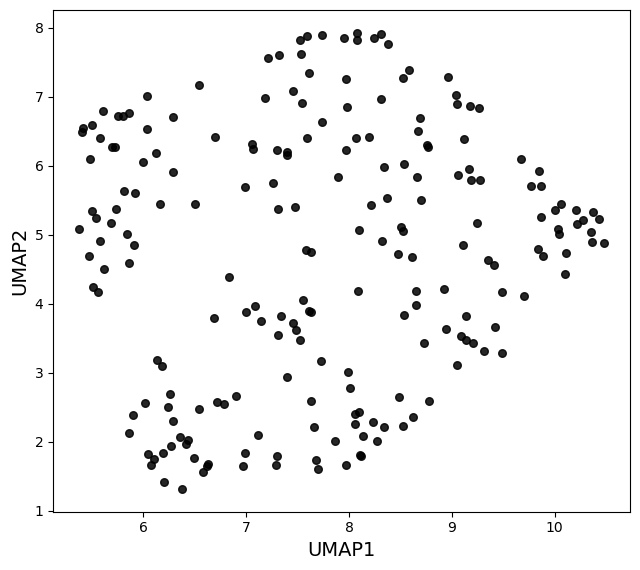

In [210]:
fig, ax = plt.subplots(figsize=(6.5, 5.8))
ax.scatter(df_use["UMAP1"], df_use["UMAP2"], s=30, alpha=0.85, color="k")
ax.set_xlabel("UMAP1", fontsize=14)
ax.set_ylabel("UMAP2", fontsize=14)
fig.tight_layout()
plt.show()

### Color UMAP by Environment

In [211]:
# Environment variables

# sigma 5
log_sigma5 = v.env['n5th_2D']

# distance to virgo
dx = v.env["distSGX_Virgo"]
dy = v.env["distSGY_Virgo"]
dz = v.env["distSGZ_Virgo"]
dist_virgo_Mpc = np.sqrt(dx**2 + dy**2 + dz**2)

# distance from Earth
dx = v.env["SGX"]
dy = v.env["SGY"]
dz = v.env["SGZ"]
dist_Mpc = np.sqrt(dx**2 + dy**2 + dz**2)

# halo mass from Kourchi & Tully
log_halo_mass = v.kt['log_Mass_lum_adapted']


In [213]:
# add columns to df_use

df_use["log_Sigma5_2d"] = np.log10(np.array(v.env["n5th_2D"])[useflag])
df_use["log_Sigma5_3d"] = np.log10(np.array(v.env["n5th"])[useflag])
df_use["dist_virgo"] = np.array(dist_virgo_Mpc)[useflag]
df_use["dist_Mpc"] = np.array(dist_Mpc)[useflag]
df_use["log_group_mass"] = np.array(v.kt["log_Mass_lum_adapted"])[useflag]

df_use["log_dist_nearest_fil_2d"] = np.log10(np.array(v.env["nearest_filament_dist_2D"])[useflag])
df_use["log_dist_nearest_fil_3d"] = np.log10(np.array(v.env["nearest_filament_dist_3D"])[useflag])

df_use["VFID"] = v.main["VFID"][useflag]
df_use["objname"] = v.main["objname"][useflag]
df_use["TAG"] = v.halpha["TAG"][useflag]

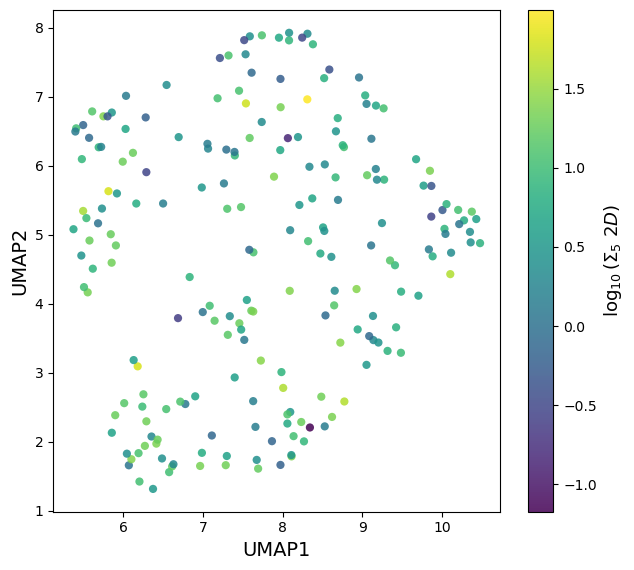

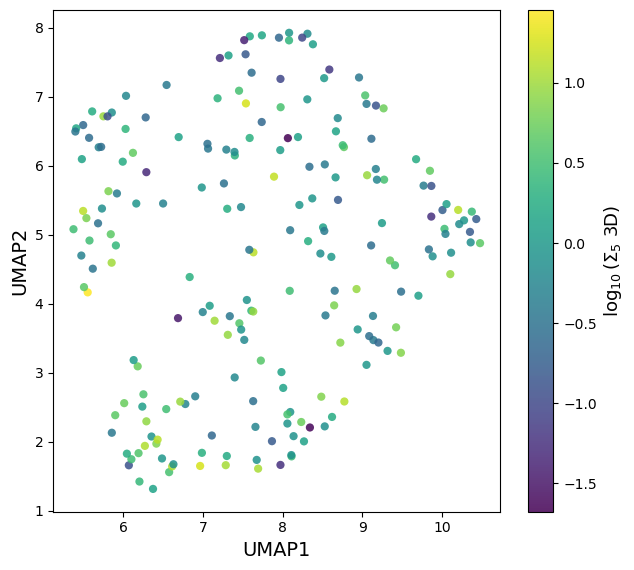

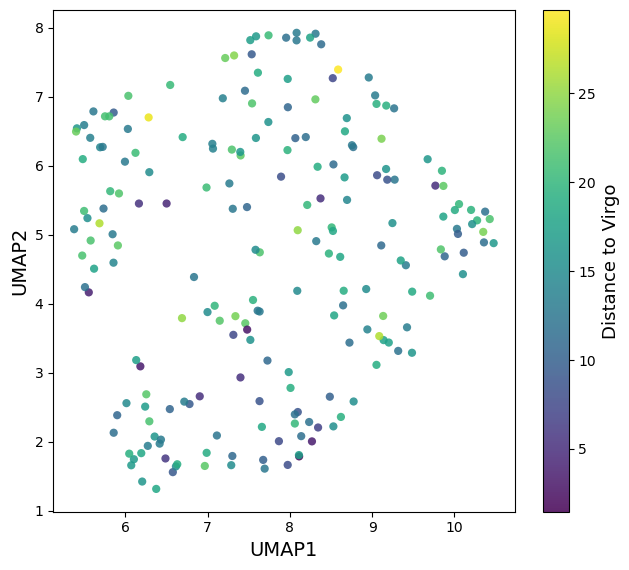

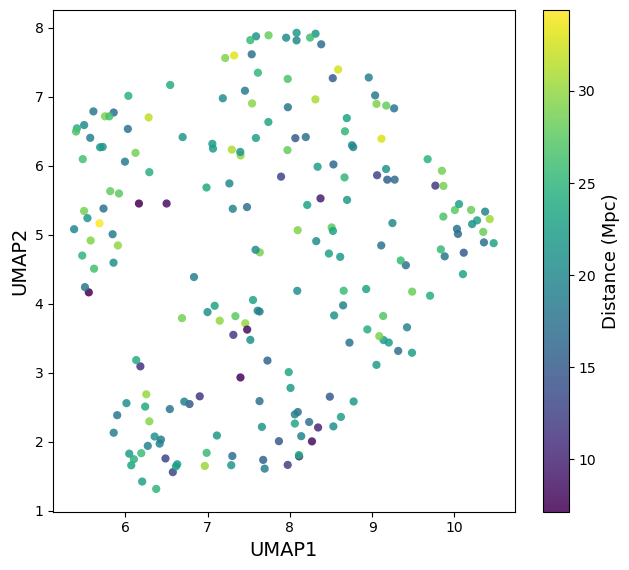

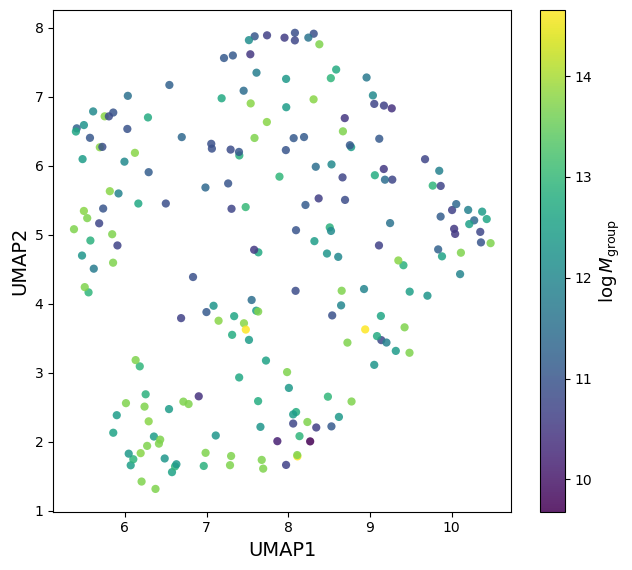

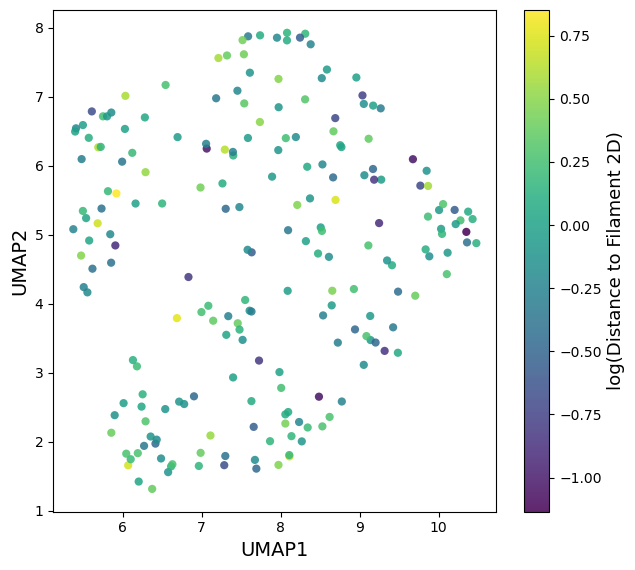

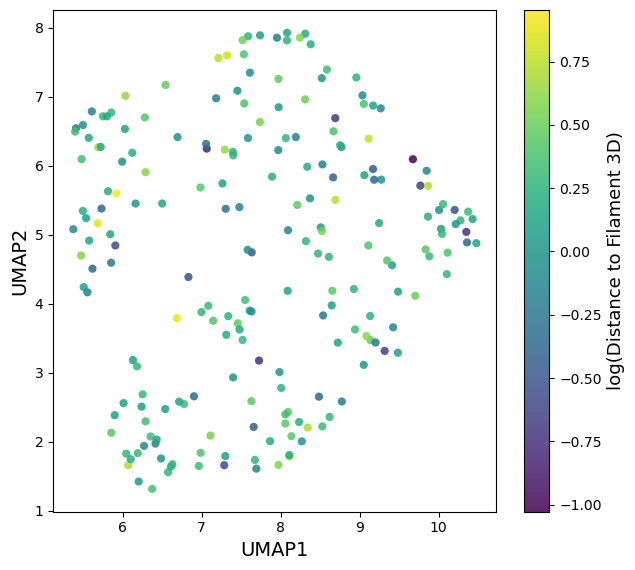

In [214]:

plot_umap_color(df_use, "log_Sigma5_2d", label=r"$\log_{10}(\Sigma_5 \ 2D)$")
plot_umap_color(df_use, "log_Sigma5_3d", label=r"$\log_{10}(\Sigma_5$ 3D)")
plot_umap_color(df_use, "dist_virgo", label="Distance to Virgo")
plot_umap_color(df_use, "dist_Mpc", label="Distance (Mpc)")
plot_umap_color(df_use, "log_group_mass", label=r"$\log M_{\rm group}$")

plot_umap_color(df_use, "log_dist_nearest_fil_2d", label=r"log(Distance to Filament 2D)")
plot_umap_color(df_use, "log_dist_nearest_fil_3d", label=r"log(Distance to Filament 3D)")

In [215]:
from scipy.stats import spearmanr
print(f"{'Variable':25s}  UMAP1        UMAP2")
print("--------------------------------------------------")
for col in feature_cols_umap:
    r1, p1 = spearmanr(df_use["UMAP1"], df_use[col])
    r2, p2 = spearmanr(df_use["UMAP2"], df_use[col])

    print(f"{col:25s}  rho1={r1:5.2f}   rho2={r2:5.2f}")

Variable                   UMAP1        UMAP2
--------------------------------------------------
logMstar                   rho1=-0.59   rho2= 0.08
dSFR                       rho1= 0.35   rho2= 0.83
g_minus_r                  rho1=-0.37   rho2=-0.82
log_flux_ratio             rho1= 0.12   rho2= 0.76
Halpha_fillfrac            rho1=-0.15   rho2= 0.89
R_C30                      rho1=-0.76   rho2= 0.16
log_outer_size_ratio       rho1= 0.12   rho2=-0.29
r_asym                     rho1= 0.24   rho2= 0.54
delta_asym                 rho1= 0.57   rho2=-0.55


In [216]:
from scipy.stats import spearmanr

env_vars = [
    "log_Sigma5_2d",
    "log_Sigma5_3d",
    "dist_virgo",
    "dist_Mpc",
    "log_group_mass",
    "log_dist_nearest_fil_2d",
    "log_dist_nearest_fil_3d"
]
print(f"{'Variable':25s}  UMAP1        UMAP2")
print("--------------------------------------------------")
for col in env_vars:
    r1, p1 = spearmanr(df_use["UMAP1"], df_use[col])
    r2, p2 = spearmanr(df_use["UMAP2"], df_use[col])

    print(f"{col:20s}  rho1={r1:5.2f}  rho2={r2:5.2f}")

Variable                   UMAP1        UMAP2
--------------------------------------------------
log_Sigma5_2d         rho1=-0.11  rho2=-0.21
log_Sigma5_3d         rho1=-0.11  rho2=-0.25
dist_virgo            rho1=-0.03  rho2= 0.16
dist_Mpc              rho1=-0.04  rho2= 0.19
log_group_mass        rho1=-0.21  rho2=-0.35
log_dist_nearest_fil_2d  rho1=-0.11  rho2=-0.02
log_dist_nearest_fil_3d  rho1=-0.05  rho2=-0.03


### Print Out Galaxies in Different Regions of UMAP space

In [227]:
import numpy as np
import pandas as pd

def add_umap_grid_labels(
    df,
    xcol="UMAP1",
    ycol="UMAP2",
    nx=3,
    ny=3,
    prefix="cell",
):
    df = df.copy()

    x_edges = np.linspace(df[xcol].min(), df[xcol].max(), nx + 1)
    y_edges = np.linspace(df[ycol].min(), df[ycol].max(), ny + 1)

    # digitize returns 1..N; convert to 0..N-1
    ix = np.digitize(df[xcol], x_edges) - 1
    iy = np.digitize(df[ycol], y_edges) - 1

    # handle objects exactly on max edge
    ix = np.clip(ix, 0, nx - 1)
    iy = np.clip(iy, 0, ny - 1)

    df["umap_ix"] = ix
    df["umap_iy"] = iy

    # label from top-left to bottom-right: A, B, C...
    # top row has highest UMAP2
    row_from_top = (ny - 1) - iy
    cell_num = row_from_top * nx + ix
    letters = np.array(list("ABCDEFGHIJKLMNOPQRSTUVWXYZ"))
    df["umap_cell"] = letters[cell_num]

    return df, x_edges, y_edges


def print_umap_grid_galaxies(
    df,
    n_per_cell=10,
    random_state=42,
    sort_by=None,
):
    cols = [
        "umap_cell",
        "VFID",
        "objname",
        "TAG",
        "UMAP1",
        "UMAP2",
        "logMstar",
        "dSFR",
        "log_flux_ratio",
        "Halpha_fillfrac",
        "delta_asym",
        "R_C30",
        "log_outer_size_ratio",
        "log_group_mass",
        "log_Sigma5_2d",
        "dist_virgo",
        "log_dist_nearest_fil_3d",
    ]

    cols = [c for c in cols if c in df.columns]

    rng = np.random.default_rng(random_state)

    for cell in sorted(df["umap_cell"].unique()):
        sub = df[df["umap_cell"] == cell].copy()

        print("\n" + "=" * 80)
        print(f"UMAP cell {cell}: N = {len(sub)}")
        print("=" * 80)

        if len(sub) == 0:
            continue

        if sort_by is not None and sort_by in sub.columns:
            sub = sub.sort_values(sort_by)
            show = sub.head(n_per_cell)
        else:
            nshow = min(n_per_cell, len(sub))
            show = sub.sample(n=nshow, random_state=random_state)

        print(
            show[cols]
            .sort_values(["UMAP2", "UMAP1"], ascending=[False, True])
            .to_string(index=False)
        )

In [228]:
df_use_grid, x_edges, y_edges = add_umap_grid_labels(
    df_use,
    nx=3,
    ny=3,
)

print_umap_grid_galaxies(
    df_use_grid,
    n_per_cell=10,
    random_state=42,
)


UMAP cell A: N = 21
umap_cell        VFID                    objname                                                        TAG    UMAP1    UMAP2  logMstar      dSFR  log_flux_ratio  Halpha_fillfrac  delta_asym    R_C30  log_outer_size_ratio  log_group_mass  log_Sigma5_2d  dist_virgo  log_dist_nearest_fil_3d
        A b'VFID3119'               b'PGC024012'                  b'VFID3119-KUG0830+278-HDI-20200226-p003' 6.544329 7.167361  8.977543  0.366046       -1.635684         0.431598    0.268467 0.339172             -0.081310          11.220       0.362277   20.475915                 0.489336
        A b'VFID1648' b'SDSSJ082718.00+460157.3'                b'VFID1648-MCG+08-16-005-HDI-20200224-p002' 6.035510 7.009871  8.640150  0.469398       -1.266853         0.379705    0.297759 0.444748             -0.243346          11.511       0.115546   21.608917                 0.633549
        A b'VFID2679'               b'PGC028169'                      b'VFID2679-MRK0408-INT-20190207-p038' 5

In [230]:
selected_for_inspection = []

for cell in sorted(df_use_grid["umap_cell"].unique()):
    sub = df_use_grid[df_use_grid["umap_cell"] == cell]
    nshow = min(10, len(sub))
    selected_for_inspection.append(
        sub.sample(n=nshow, random_state=42)
    )

inspect_tab = pd.concat(selected_for_inspection).sort_values("umap_cell")

inspect_tab.to_csv("umap_grid_visual_inspection_sample.csv", index=False)

inspect_tab[
    ["umap_cell", "VFID", "objname", "TAG","UMAP1", "UMAP2",
     "logMstar", "dSFR", "log_flux_ratio",
     "Halpha_fillfrac", "delta_asym", "log_group_mass"]
].head()

,umap_cell,VFID,objname,TAG,UMAP1,UMAP2,logMstar,dSFR,log_flux_ratio,Halpha_fillfrac,delta_asym,log_group_mass
715,A,b'VFID0715',b'PGC036687',b'VFID0715-SBS1143+588-BOK-20210418-VFID0788',6.029663,6.530190,8.683035,0.065231,-1.844626,0.240554,0.742652,10.944
3349,A,b'VFID3349',b'IC2268',b'VFID3349-IC2268-INT-20190207-lmp002',6.695892,6.411784,8.645854,0.524783,-1.822630,0.251065,1.271699,11.367
3119,A,b'VFID3119',b'PGC024012',b'VFID3119-KUG0830+278-HDI-20200226-p003',6.544329,7.167361,8.977543,0.366046,-1.635684,0.431598,0.268467,11.220
1648,A,b'VFID1648',b'SDSSJ082718.00+460157.3',b'VFID1648-MCG+08-16-005-HDI-20200224-p002',6.035510,7.009871,8.640150,0.469398,-1.266853,0.379705,0.297759,11.511
2462,A,b'VFID2462',b'PGC035503',b'VFID2462-KUG1128+358-BOK-20210417-VFID2484',7.064702,6.245239,8.903895,-0.237038,-1.721701,0.220174,1.260482,10.912


In [231]:
n_clusters = 9

from sklearn.cluster import KMeans

kmeans = KMeans(
    n_clusters=9,
    random_state=42,
    n_init="auto",
)

labels = kmeans.fit_predict(df_use[["UMAP1","UMAP2"]])
centers = kmeans.cluster_centers_

df_use["cluster"] = labels

In [232]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

def make_umap_kmeans_regions(
    df,
    n_regions=9,
    xcol="UMAP1",
    ycol="UMAP2",
    random_state=42,
    region_col="umap_region",
):
    df = df.copy()

    X = df[[xcol, ycol]].values

    kmeans = KMeans(
        n_clusters=n_regions,
        random_state=random_state,
        n_init="auto",
    )

    labels = kmeans.fit_predict(X)
    centers = kmeans.cluster_centers_

    # Sort regions from top-left to bottom-right for intuitive labels.
    # First sort by descending y, then ascending x.
    order = np.lexsort((centers[:, 0], -centers[:, 1]))

    letters = np.array(list("ABCDEFGHIJKLMNOPQRSTUVWXYZ"))
    region_names = letters[:n_regions]

    label_to_region = {}
    sorted_centers = np.zeros_like(centers)

    for new_i, old_i in enumerate(order):
        label_to_region[old_i] = region_names[new_i]
        sorted_centers[new_i] = centers[old_i]

    df[region_col] = [label_to_region[l] for l in labels]
    df[f"{region_col}_id"] = labels

    centers_df = pd.DataFrame(
        {
            region_col: region_names,
            f"{xcol}_center": sorted_centers[:, 0],
            f"{ycol}_center": sorted_centers[:, 1],
        }
    )

    return df, centers_df, kmeans

def select_representative_umap_galaxies(
    df,
    centers_df,
    n_per_region=10,
    xcol="UMAP1",
    ycol="UMAP2",
    region_col="umap_region",
):
    selected = []

    for _, row in centers_df.iterrows():
        region = row[region_col]
        xc = row[f"{xcol}_center"]
        yc = row[f"{ycol}_center"]

        sub = df[df[region_col] == region].copy()

        sub["dist_to_region_center"] = np.hypot(
            sub[xcol] - xc,
            sub[ycol] - yc,
        )

        sub = sub.sort_values("dist_to_region_center")
        selected.append(sub.head(n_per_region))

    selected = pd.concat(selected, ignore_index=True)
    return selected

def plot_umap_kmeans_regions(
    df,
    centers_df,
    selected=None,
    xcol="UMAP1",
    ycol="UMAP2",
    region_col="umap_region",
    outfile=None,
    show=True,
):
    fig, ax = plt.subplots(figsize=(7.5, 6.5))

    regions = sorted(df[region_col].unique())

    for region in regions:
        sub = df[df[region_col] == region]

        ax.scatter(
            sub[xcol],
            sub[ycol],
            s=25,
            alpha=0.7,
            label=region,
        )

    # Plot centroids and labels
    for _, row in centers_df.iterrows():
        region = row[region_col]
        xc = row[f"{xcol}_center"]
        yc = row[f"{ycol}_center"]

        ax.scatter(
            xc,
            yc,
            s=400,
            marker="X",
            color="k",
            zorder=5,
        )

        ax.text(
            xc,
            yc,
            region,
            ha="center",
            va="center",
            fontsize=13,
            color="white",
            fontweight="bold",
            zorder=6,
        )

    # Highlight selected representative galaxies
    if selected is not None:
        ax.scatter(
            selected[xcol],
            selected[ycol],
            s=120,
            facecolors="none",
            edgecolors="k",
            linewidths=2,
            zorder=4,
        )

    ax.set_xlabel("UMAP1", fontsize=14)
    ax.set_ylabel("UMAP2", fontsize=14)
    ax.set_title("Representative UMAP regions", fontsize=16)

    ax.legend(
        title="Region",
        fontsize=9,
        title_fontsize=10,
        loc="best",
        frameon=True,
        ncol=2,
    )

    fig.tight_layout()

    if outfile is not None:
        fig.savefig(outfile, dpi=200, bbox_inches="tight")

    if show:
        plt.show()
    else:
        plt.close(fig)

In [235]:
df_use["TAG"]

487            b'VFID0487-UGC06691-BOK-20210417-VFID0520'
496     b'VFID0496-WISEAJ114601.22+603006.0-BOK-202104...
680     b'VFID0680-WISEAJ114552.80+584811.0-BOK-202104...
715         b'VFID0715-SBS1143+588-BOK-20210418-VFID0788'
731     b'VFID0731-SDSSJ151827.05+582658.5-BOK-2022042...
                              ...                        
6519    b'VFID6519-SDSSJ150349.93+005831.7-BOK-2022042...
6536    b'VFID6536-2MASXJ15090433+0049185-BOK-20220426...
6539    b'VFID6539-WISEAJ151231.73+004845.5-BOK-202204...
6552            b'VFID6552-MRK1390-BOK-20220428-VFID6503'
6590    b'VFID6590-PGC10053932NED076-MOS-20120418-NGC5...
Name: TAG, Length: 209, dtype: bytes480

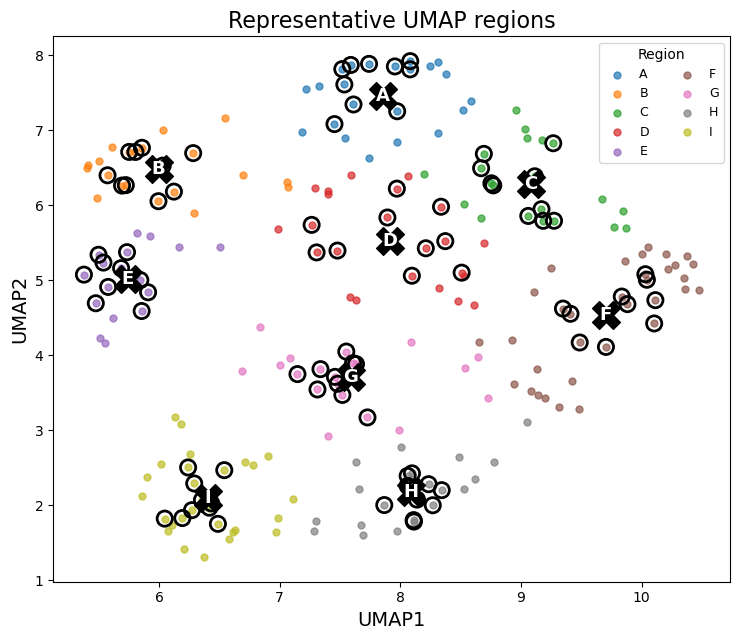

In [236]:
df_umap_regions, centers_df, kmeans = make_umap_kmeans_regions(
    df_use,
    n_regions=9,
    random_state=42,
)

selected_umap = select_representative_umap_galaxies(
    df_umap_regions,
    centers_df,
    n_per_region=10,
)
#selected_umap["TAG"] = df_use["TAG"]
plot_umap_kmeans_regions(
    df_umap_regions,
    centers_df,
    selected=selected_umap,
    outfile="umap_kmeans_regions_selected.png",
)

In [237]:

letters = sorted(selected_umap["umap_region"].unique())

#print(letters)

cols = [
    "VFID",
    "objname",
    "TAG",
    "logMstar",
    "dSFR",
    "g_minus_r",
    "log_flux_ratio",
    "Halpha_fillfrac",
    "delta_asym",
    "R_C30",
    "log_group_mass",
]
selected_umap["VFID"] = selected_umap["VFID"].str.decode("utf-8")
for letter in letters:
    print("\n" + "="*80)
    print(f"Region {letter}")
    print("="*80)

    flag = selected_umap["umap_region"] == letter

    sub = (
        selected_umap.loc[flag, cols]
        .sort_values("VFID")
    )

    print(sub.to_string(index=False))
    
    
# for letter in letters:
#     flag = selected_umap["umap_region"] == letter
#     print(selected_umap[flag])


Region A
    VFID                    objname                                                        TAG  logMstar     dSFR  g_minus_r  log_flux_ratio  Halpha_fillfrac  delta_asym    R_C30  log_group_mass
VFID1820               b'PGC029699'              b'VFID1820-KUG1008+436-BOK-20210416-VFID1844'  8.511747 0.497145   0.150269       -1.418513         0.448556    1.123027 0.287170          11.788
VFID1964              b'PGC2184231' b'VFID1964-WISEAJ134900.04+413758.6-BOK-20220425-VFID1979'  7.613118 0.718793   0.093609       -1.158308         0.412338    0.519137 0.334241          10.650
VFID2193              b'PGC2145202' b'VFID2193-WISEAJ120959.89+391147.3-INT-20220503-VFID2171'  7.736314 0.039755   0.144403       -1.427322         0.347285    0.642956 0.335241          10.489
VFID2545              b'PGC2053079' b'VFID2545-WISEAJ113947.32+344133.6-BOK-20220428-VFID2601'  7.732113 0.511332   0.081802       -1.052456         0.349727    0.972489 0.302872          10.582
VFID2715       

In [114]:
set(selected_umap["umap_region"])

{'A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I'}

In [241]:
# Decode bytes columns if needed
for col in ["VFID", "objname", "TAG", "umap_region"]:
    if col in selected_umap.columns:
        selected_umap[col] = selected_umap[col].apply(
            lambda x: x.decode("utf-8") if isinstance(x, bytes) else x
        )

# Columns needed for contact-sheet generation + useful context
contact_cols = [
    "umap_region",
    "VFID",
    "objname",
    "TAG",
    "UMAP1",
    "UMAP2",
    "dist_to_region_center",
    "logMstar",
    "dSFR",
    "g_minus_r",
    "log_flux_ratio",
    "Halpha_fillfrac",
    "delta_asym",
    "R_C30",
    "log_group_mass",
]

contact_cols = [c for c in contact_cols if c in selected_umap.columns]

contact_table = (
    selected_umap[contact_cols]
    .sort_values(["umap_region", "VFID"])
    .reset_index(drop=True)
)

outfile = os.path.join('/Users/rfinn/research/Virgo/hapypost/tables/hapy-output-20260620/ML/',"umap_region_contact_sheet_input.csv")
contact_table.to_csv(outfile, index=False)

print(f"Wrote {len(contact_table)} rows to {outfile}")

Wrote 90 rows to /Users/rfinn/research/Virgo/hapypost/tables/hapy-output-20260620/ML/umap_region_contact_sheet_input.csv


'/Users/rfinn/research/Virgo/hapypost/plots/'